# TruePneumoniaAI : Analyse exploratoire des données

Ce notebook analyse le dataset `chest_Xray/` avant l'entraînement :
1. Distribution des classes
2. Galerie d'images
3. Dimensions et qualité des images
4. Aperçu des augmentations
5. Déséquilibre et calcul du pos_weight

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import random

DATA_DIR = Path('../chest_Xray')
SPLITS = ['train', 'val', 'test']
CLASSES = ['NORMAL', 'PNEUMONIA']
random.seed(42)

## 1. Distribution des classes

In [2]:
counts = {}
for split in SPLITS:
    counts[split] = {}
    for cls in CLASSES:
        p = DATA_DIR / split / cls
        counts[split][cls] = len(list(p.glob('*.jpeg')) + list(p.glob('*.jpg')))

print(f"{'Split':<8} {'NORMAL':>10} {'PNEUMONIA':>12} {'Total':>8} {'Ratio P/N':>10}")
print('-' * 52)
for split in SPLITS:
    n = counts[split]['NORMAL']
    p = counts[split]['PNEUMONIA']
    ratio = p / n if n > 0 else float('inf')
    print(f"{split:<8} {n:>10} {p:>12} {n+p:>8} {ratio:>10.2f}x")

Split        NORMAL    PNEUMONIA    Total  Ratio P/N
----------------------------------------------------
train          1341         3875     5216       2.89x
val               8            8       16       1.00x
test            234          390      624       1.67x


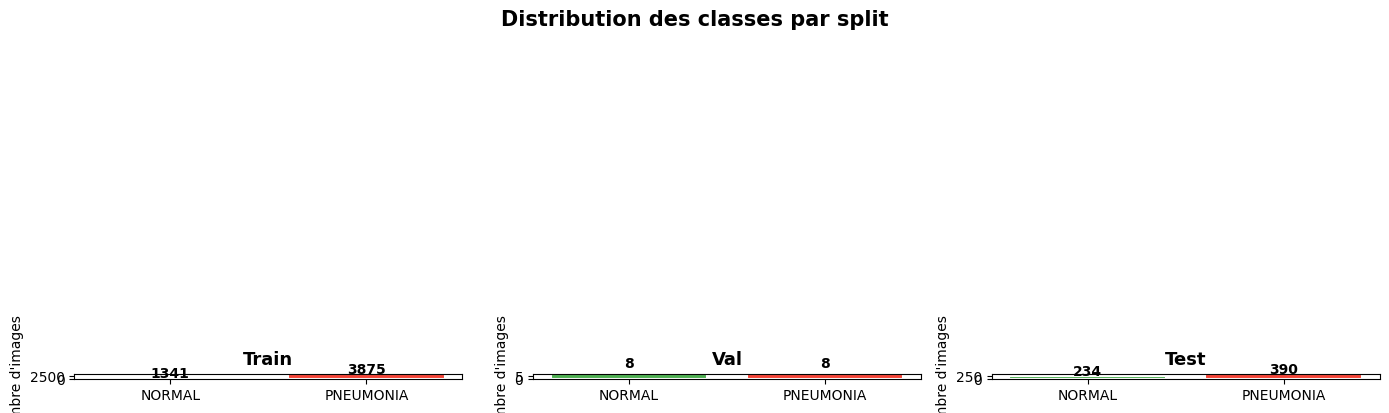

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#4CAF50', '#F44336']

for ax, split in zip(axes, SPLITS):
    values = [counts[split][c] for c in CLASSES]
    bars = ax.bar(CLASSES, values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{split.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Nombre d\'images')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(val), ha='center', fontweight='bold')
    ax.set_ylim(0, max(values) * 1.15)

plt.suptitle('Distribution des classes par split', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 2. Galerie d'images : NORMAL vs PNEUMONIA

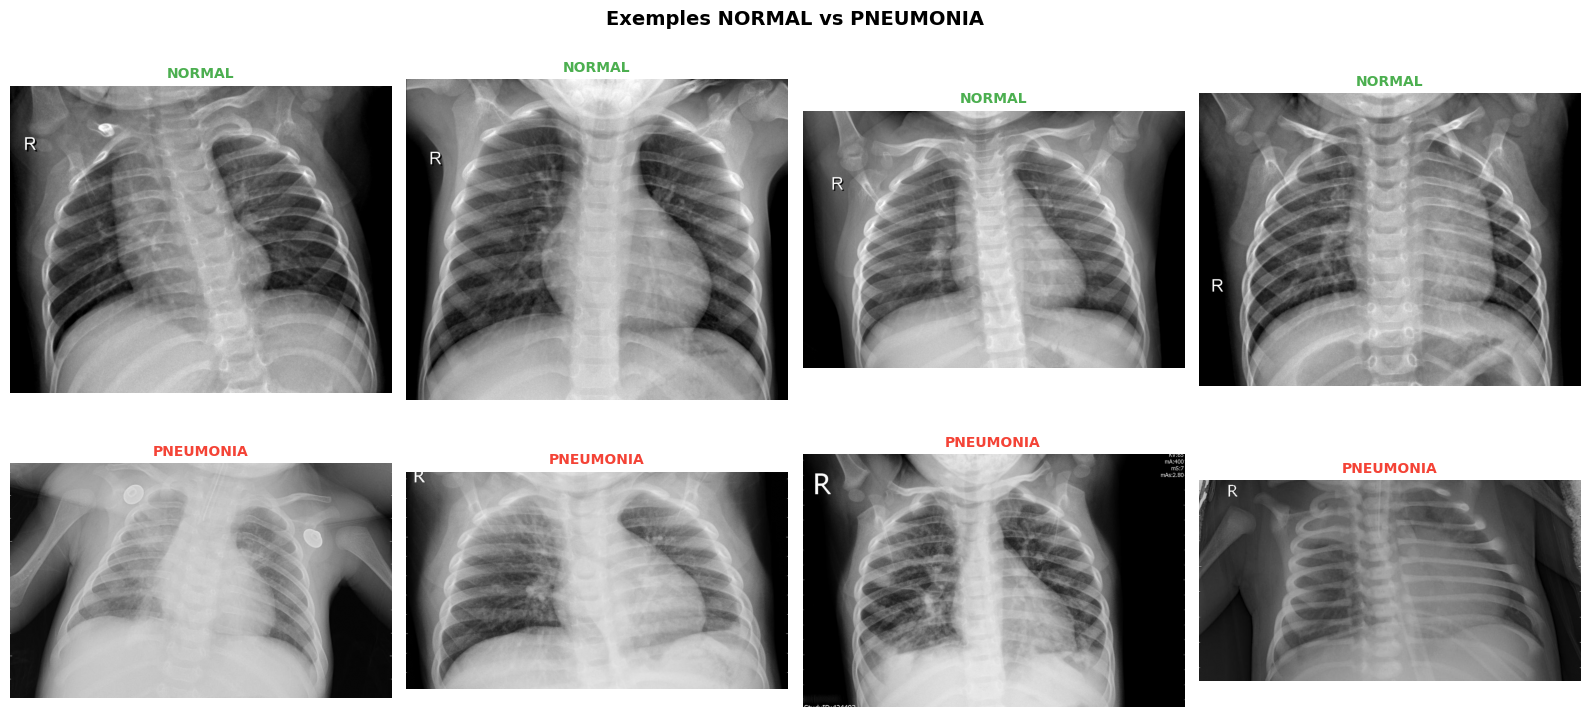

In [4]:
def sample_images(cls, split='train', n=4):
    p = DATA_DIR / split / cls
    imgs = list(p.glob('*.jpeg')) + list(p.glob('*.jpg'))
    return random.sample(imgs, min(n, len(imgs)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, cls in enumerate(CLASSES):
    samples = sample_images(cls, n=4)
    for col, img_path in enumerate(samples):
        img = Image.open(img_path).convert('L')
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls, fontsize=10,
                                  color='#4CAF50' if cls == 'NORMAL' else '#F44336',
                                  fontweight='bold')
        axes[row, col].axis('off')
        axes[row, col].set_xlabel(img_path.name, fontsize=7)

plt.suptitle('Exemples NORMAL vs PNEUMONIA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/sample_images.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Analyse des dimensions

In [5]:
# Echantillon de 200 images par classe pour ne pas charger tout le dataset
SAMPLE_SIZE = 200
dim_data = {cls: {'widths': [], 'heights': [], 'aspects': []} for cls in CLASSES}

for cls in CLASSES:
    p = DATA_DIR / 'train' / cls
    imgs = list(p.glob('*.jpeg')) + list(p.glob('*.jpg'))
    sample = random.sample(imgs, min(SAMPLE_SIZE, len(imgs)))
    for img_path in sample:
        with Image.open(img_path) as img:
            w, h = img.size
            dim_data[cls]['widths'].append(w)
            dim_data[cls]['heights'].append(h)
            dim_data[cls]['aspects'].append(w / h)

print(f"{'Classe':<12} {'Largeur moy':>12} {'Hauteur moy':>12} {'Aspect ratio moy':>18}")
print('-' * 56)
for cls in CLASSES:
    w_mean = np.mean(dim_data[cls]['widths'])
    h_mean = np.mean(dim_data[cls]['heights'])
    a_mean = np.mean(dim_data[cls]['aspects'])
    print(f"{cls:<12} {w_mean:>12.0f} {h_mean:>12.0f} {a_mean:>18.3f}")

Classe        Largeur moy  Hauteur moy   Aspect ratio moy
--------------------------------------------------------
NORMAL               1661         1374              1.224
PNEUMONIA            1155          784              1.536


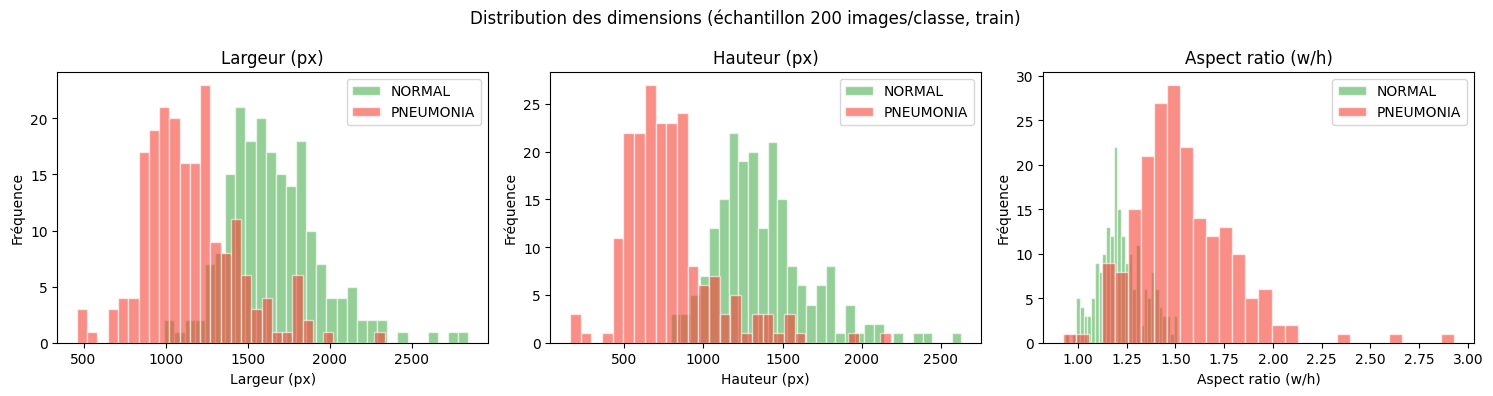

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'NORMAL': '#4CAF50', 'PNEUMONIA': '#F44336'}
keys = ['widths', 'heights', 'aspects']
labels = ['Largeur (px)', 'Hauteur (px)', 'Aspect ratio (w/h)']

for ax, key, label in zip(axes, keys, labels):
    for cls in CLASSES:
        ax.hist(dim_data[cls][key], bins=30, alpha=0.6,
                color=colors[cls], label=cls, edgecolor='white')
    ax.set_xlabel(label)
    ax.set_ylabel('Fréquence')
    ax.legend()
    ax.set_title(label)

plt.suptitle('Distribution des dimensions (échantillon 200 images/classe, train)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/image_dimensions.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Histogrammes d'intensité

In [ ]:
# Intensité pixel sur 50 images par classe
intensity_data = {cls: [] for cls in CLASSES}

for cls in CLASSES:
    p = DATA_DIR / 'train' / cls
    imgs = list(p.glob('*.jpeg')) + list(p.glob('*.jpg'))
    for img_path in random.sample(imgs, min(50, len(imgs))):
        arr = np.array(Image.open(img_path).convert('L')).flatten()
        intensity_data[cls].extend(arr.tolist())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, cls in zip(axes, CLASSES):
    ax.hist(intensity_data[cls], bins=64, color=colors[cls], alpha=0.8, edgecolor='white')
    ax.set_title(f'Intensité — {cls}', fontweight='bold')
    ax.set_xlabel('Valeur pixel (0–255)')
    ax.set_ylabel('Fréquence')
    mean_val = np.mean(intensity_data[cls])
    ax.axvline(mean_val, color='white', linestyle='--', label=f'Moy: {mean_val:.0f}')
    ax.legend()

plt.suptitle('Histogrammes d\'intensité (50 images/classe)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/intensity_histograms.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Aperçu des augmentations Albumentations

C:\Users\pol\AppData\Local\Temp\ipykernel_27208\1033354759.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  ('GaussNoise', A.GaussNoise(var_limit=(30, 60), p=1.0)),


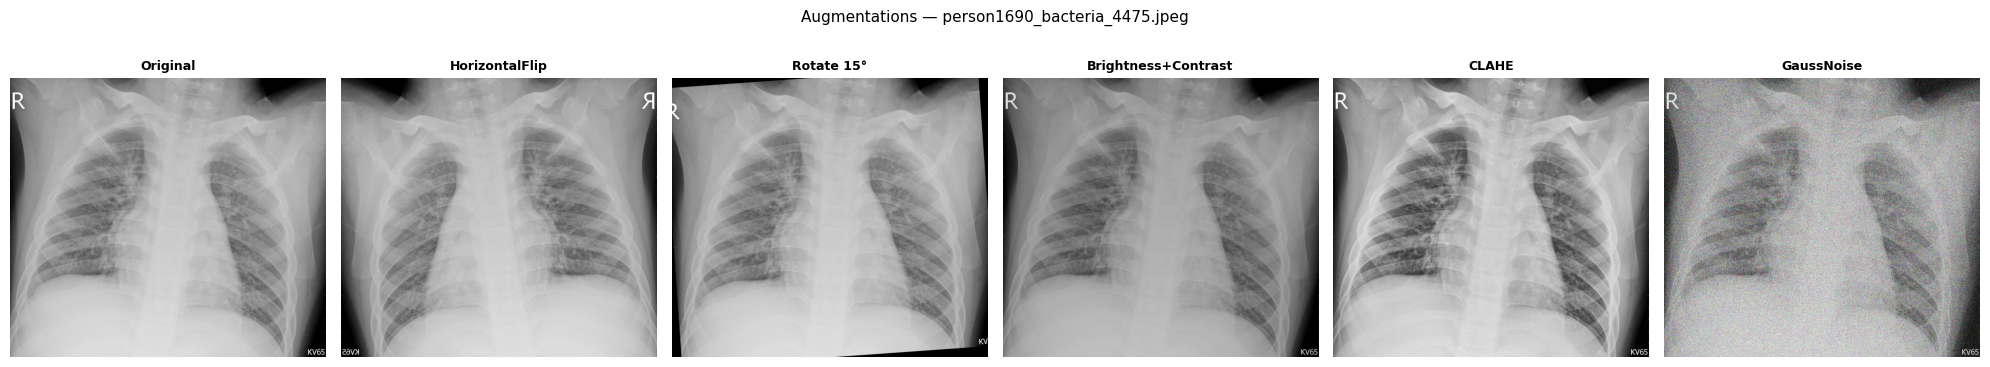

In [8]:
import albumentations as A

# Prendre une image PNEUMONIA representative
sample_path = random.choice(
    list((DATA_DIR / 'train' / 'PNEUMONIA').glob('*.jpeg'))
)
original = np.array(Image.open(sample_path).convert('RGB'))

transforms_showcase = [
    ('Original', None),
    ('HorizontalFlip', A.HorizontalFlip(p=1.0)),
    ('Rotate 15°', A.Rotate(limit=15, p=1.0)),
    ('Brightness+Contrast', A.RandomBrightnessContrast(0.3, 0.3, p=1.0)),
    ('CLAHE', A.CLAHE(clip_limit=3.0, p=1.0)),
    ('GaussNoise', A.GaussNoise(var_limit=(30, 60), p=1.0)),
]

fig, axes = plt.subplots(1, len(transforms_showcase), figsize=(20, 4))

for ax, (name, transform) in zip(axes, transforms_showcase):
    if transform is None:
        img = original
    else:
        img = transform(image=original)['image']
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Augmentations — {sample_path.name}', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/augmentation_preview.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Déséquilibre et pos_weight

Train NORMAL    : 1341
Train PNEUMONIA : 3875
Ratio P/N       : 2.89x

pos_weight = 1341/3875 = 0.3461

Ce poids est passé à BCEWithLogitsLoss pour pénaliser
davantage les faux négatifs PNEUMONIA pendant l'entraînement.


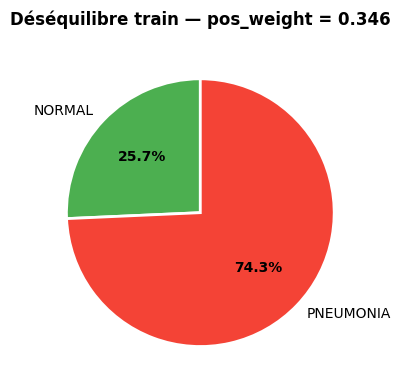

In [9]:
n_normal = counts['train']['NORMAL']
n_pneumonia = counts['train']['PNEUMONIA']
pos_weight = n_normal / n_pneumonia

print(f"Train NORMAL    : {n_normal}")
print(f"Train PNEUMONIA : {n_pneumonia}")
print(f"Ratio P/N       : {n_pneumonia / n_normal:.2f}x")
print()
print(f"pos_weight = {n_normal}/{n_pneumonia} = {pos_weight:.4f}")
print()
print("Ce poids est passé à BCEWithLogitsLoss pour pénaliser")
print("davantage les faux négatifs PNEUMONIA pendant l'entraînement.")

fig, ax = plt.subplots(figsize=(6, 4))
wedges, texts, autotexts = ax.pie(
    [n_normal, n_pneumonia],
    labels=CLASSES,
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontweight('bold')
ax.set_title(f'Déséquilibre train — pos_weight = {pos_weight:.3f}',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/class_imbalance.png', bbox_inches='tight', dpi=150)
plt.show()

---
**Conclusion :** le dataset est déséquilibré (~3x plus de PNEUMONIA). Le `pos_weight` calculé compense cela sans sur-échantillonner. La suite : `python -m src.training.train --config configs/default.yaml`.